# Example Firefly usage

This builds off of the [minimal example](https://firefly.rcs.northwestern.edu/docs/data_reader/minimal_example.html) from our docs and the new [data selection example](https://github.com/ageller/Firefly/blob/main/src/firefly/ntbks/selecting_data.ipynb) from our GitHub repo.


As an example, we will generate two random particle sets (a sphere and a cube) both with a randomized attribute field.  We will load these data into Firefly.

This notebook also demonstrates how to retrieve data that you selected by hand in the Firefly app and then use those data with your notebook. 

In [1]:
import numpy as np

In [2]:
# Load your data. Here we're creating random data.

# one particle set (sphere)
coords_sphere = np.random.randn( 20000, 3 )
fields_sphere = np.random.random(size=coords_sphere[:,0].size)

# a second particle set (cube)
coords_cube = np.random.rand( 20000, 3 ) - 0.5
fields_cube = np.random.random(size=coords_cube[:,0].size)

## Format Data for Firefly

Here are the docs for [Reader](https://firefly.rcs.northwestern.edu/docs/reference/api/classes/firefly.data_reader.Reader.html#firefly.data_reader.Reader) and [ParticleGroup](https://firefly.rcs.northwestern.edu/docs/reference/api/classes/firefly.data_reader.ParticleGroup.html#firefly.data_reader.ParticleGroup) and also [a tutorial for using these](https://firefly.rcs.northwestern.edu/docs/data_reader/reader_tutorial.html).  Also note that for simple data (e.g., one particle group), you can use the [ArrayReader](https://firefly.rcs.northwestern.edu/docs/reference/api/readers/firefly.data_reader.ArrayReader.html) class.

In [3]:
from firefly.data_reader import ParticleGroup, Reader

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [4]:
# create two Firefly particle groups
sphere = ParticleGroup(
    'sphere',
    coords_sphere,
    field_arrays=[fields_sphere], 
    field_names=['rands']
) 

cube = ParticleGroup(
    'cube',
    coords_cube,
    field_arrays=[fields_cube], 
    field_names=['randc']
) 

# create the Reader
my_reader = Reader()

# add the particle groups to the reader
my_reader.addParticleGroup(sphere)
my_reader.addParticleGroup(cube)


Make sure each field_array (1) has a field_filter_flag (0), assuming True.
Make sure each field_array (1) has a field_colormap_flag (0), assuming True.
Make sure each field_array (1) has a field_radius_flag (0), assuming False.
Make sure each field_array (1) has a field_filter_flag (0), assuming True.
Make sure each field_array (1) has a field_colormap_flag (0), assuming True.
Make sure each field_array (1) has a field_radius_flag (0), assuming False.
datadir is None, defaulting to /Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data


## Display Inline

In [5]:
# Firefly was built using the `eventlet` library, which is now deprecated.  (We still need to migrate to a newer library.)
# Let's silence the deprecation warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
from firefly.server import spawnFireflyServer,quitAllFireflyServers

In [7]:
# define the local port (typically anything in 5000 - 8000 range)
port = 5500

In [8]:
# Note: you should only run this cell once.  You only want one single Firefly server running at time on your machine.
# If you've already run this cell and need to restart the server for some reason, the best thing to do is to restart your notebook kernel.
# (You can continue to send new data to the existing server, within needing to re-run this cell.)
process = spawnFireflyServer(port, method = 'flask')

Waiting up to 10 seconds for background Firefly server to start......Launching Firefly at: http://localhost:5500
from directory /Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly


/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event
 * Restarting with stat


.Launching Firefly at: http://localhost:5500
from directory /Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly
done! Your server is available at - http://localhost:5500


/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


In [13]:
# Send data to the server.
# Wait until it loads to run this command
my_reader.sendDataViaFlask()

sphere - 20000/20000 particles - 1 tracked fields
cube - 20000/20000 particles - 1 tracked fields
Posting data on port 5500...======= receiving data from server ...
======= size of data 2124876
======= showing loader
======= sending data to viewer ...
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/Datasphere000.json 1061545
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/Datacube000.json 1061229
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/DataSettings.json 1019
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/filenames.json 131
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/startup.json 45
======= done
data posted!


## Get the selected data in Python

(after using the selection tool)

In [14]:
import requests

import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
# send a get request to receive the current settings from Firefly
# for larger amounts of data, you will need to increase the waitTime (in seconds) via params (see below; the default is 10s)
r = requests.get(url = f'http://localhost:{port:d}/get_selected_data', params = {'waitTime':60})
if r.status_code == 200:
    # success
    selection = r.json()
    # as a check
    partsKeys = list(selection.keys())
    print(partsKeys)
    print(selection[partsKeys[0]]['Coordinates_flat'][:100]) 
else:
    print('Error: {}'.format(r.status_code), r.content)


======= received request for selected data from user
======= gettings selected data, waiting 60s
['sphere', 'cube']
[-1.4954855812, -1.6080483455, 1.0927826691, 0.6792085206, -1.8965123608, 1.3851992612, -2.6481518619, -1.4079305709, 0.9096784288, 1.0615192358, -2.9164662353, 1.4141491723, -1.1464557213, -1.6116826287, 0.7594752722, -0.4051192038, -1.954286729, 0.8191877692, -1.6404024261, -1.8717125911, 0.9732723147, -0.9835191759, -1.5542372871, 1.3874806806, -0.6952807238, -2.7069894606, 0.0038010762, -0.6182758691, -1.9707351764, 0.8877936524, 0.31728171, -1.8943000737, 1.6090526552, -0.8416327744, -2.4414894308, 0.8942563795, 0.5545551013, -2.5886381282, 0.0236494486, -0.3282745696, -2.0752959035, 0.3834065268, 0.6294052793, -2.4475947016, 1.1796316994, 0.2623929466, -2.4983126848, -0.2529727351, -1.1017945715, -2.5489650226, -0.2233838964, 0.2528170114, -2.2771389111, 1.7138857956, -1.3697890867, -2.216581794, 1.207847168, -0.1445654512, -2.3677998975, 0.6708106387, -1.1964345291

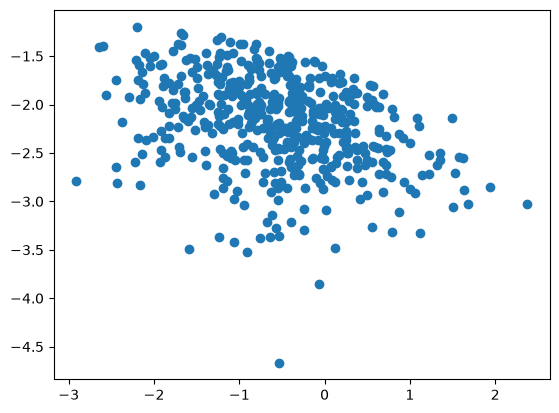

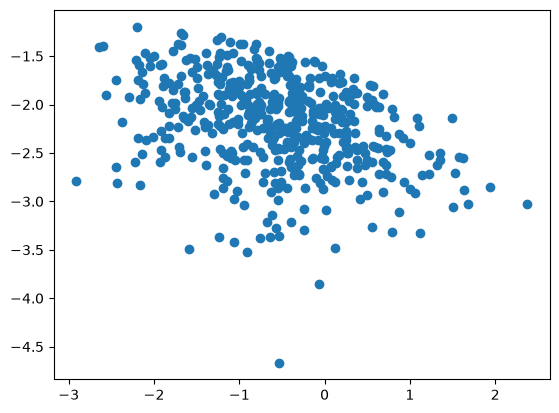

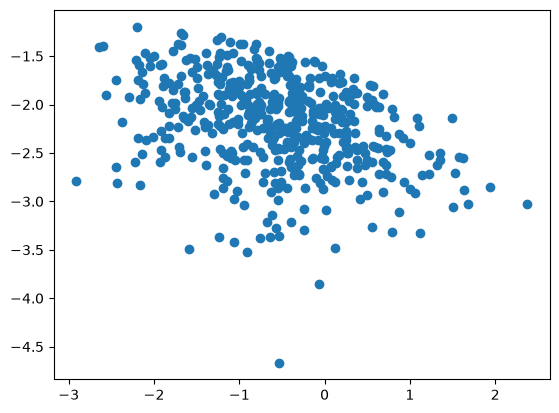

In [20]:
# plot x, y for the selected points
partsKeys = list(selection.keys())
part0 = selection[partsKeys[0]]

# UPDATE THIS
x = part0['Coordinates_flat'][0::3]
y = part0['Coordinates_flat'][1::3]

f, ax = plt.subplots()
ax.scatter(x[:1000],y[:1000])
plt.show()

### Quit the Firefly server

... this doesn't always work in a notebook ... you can also quit the server by resetting the kernel.

In [ ]:
return_code = quitAllFireflyServers()

# Exercise: viz SN Ia from BTS

for simplicity (short amount of time), x,y will be Ra,DEC rather than real positions, and z will be redshift

In [29]:
! pip install astropy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 4.5 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 6.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [astropy]m2/3 [astropy]


In [42]:
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames

In [65]:
rtab = pd.read_csv('explorer-Ia.txt')
rtab.columns

Index(['ZTFID', 'IAUID', 'RA', 'Dec', 'peakt', 'peakfilt', 'peakmag',
       'peakabs', 'duration', 'rise', 'fade', 'type', 'redshift', 'b', 'A_V'],
      dtype='str')

In [53]:
rtab = pd.read_csv('explorer-Ia.txt')
print(rtab['RA'][0], rtab['Dec'][0])

# represent the coordinates as a SkyCoord object
coords = SkyCoord(ra=rtab['RA'], dec=rtab['Dec'], unit=(u.hourangle, u.deg), frame='icrs')
coords


10:35:32.09 +37:38:59.0


<SkyCoord (ICRS): (ra, dec) in deg
    [(158.88370833,  37.64972222), ( 47.35145833,  -4.89422222),
     (127.44829167,  33.90633333), ..., (312.881125  , -19.48608333),
     (358.9105    ,  11.29638889), (330.11808333,  36.68152778)]>

In [62]:
# now define a numpy array of these coordinates in degrees, consistent w shaping like in this example:
## coords_sphere = np.random.randn( 20000, 3 )
## fields_sphere = np.random.random(size=coords_sphere[:,0].size)

coords_array = np.zeros((len(coords), 3))
coords_array[:,0] = coords.ra.deg
coords_array[:,1] = coords.dec.deg
# coords_array[:,2] = rtab['redshift']
# redshift is sooo small ... but I want to be able to visualize it. 
coords_array[:,2] = rtab['redshift'] * 1000  # Scale up for visualization
coords_array

array([[158.88370833,  37.64972222,  69.22      ],
       [ 47.35145833,  -4.89422222,  72.        ],
       [127.44829167,  33.90633333,  62.        ],
       ...,
       [312.881125  , -19.48608333,  96.        ],
       [358.9105    ,  11.29638889,  79.        ],
       [330.11808333,  36.68152778,  81.        ]], shape=(4375, 3))

In [71]:
fields_snIa =   rtab['peakmag'].values

# create Firefly particle group
snIa = ParticleGroup(
    'snIa',
    coords_array,
    field_arrays=[fields_snIa], 
    field_names=['rands']
) 

# create the Reader
my_reader = Reader()

# add the particle groups to the reader
my_reader.addParticleGroup(snIa)

Make sure each field_array (1) has a field_filter_flag (0), assuming True.
Make sure each field_array (1) has a field_colormap_flag (0), assuming True.
Make sure each field_array (1) has a field_radius_flag (0), assuming False.
datadir is None, defaulting to /Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data


In [ ]:
# Send data to the server.
# Wait until it loads to run this command
my_reader.sendDataViaFlask()

snIa - 4375/4375 particles - 1 tracked fields
Posting data on port 5500...======= receiving data from server ...
======= size of data 175186
======= showing loader
======= sending data to viewer ...
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/DatasnIa000.json 173692
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/DataSettings.json 662
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/Data/filenames.json 84
/Users/saarahhall/miniconda3/envs/fireflyenv/lib/python3.11/site-packages/firefly/static/data/startup.json 45
======= done
data posted!


======= sid CPfnhgE0YMxwvQGXAAAR disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid CYMERcEBnA5cbSpRAAAT disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid e3A5BQwUVwK728lbAAAV disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid HieXmins36166i4BAAAX disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connecte

In [9]:
from IPython.display import IFrame
url = f'http://localhost:{port:d}/combined'
IFrame(url, width=1000, height=500)

======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid Bral_kclax_g5VhhAAAB disconnected from room default_Firefly_AMG_ABG
======= sid N0S7PcIOxRGLoUwwAAAD disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
======= sid ZpdqXgmobdlB3x7mAAAF disconnected fr